<a href="https://colab.research.google.com/github/roomeroo/Cuadernos-de-jupyter/blob/main/Algoritmo_Dijkstra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmo de Dijikstra

## Clase Nodo

In [213]:
from collections import deque

class Nodo:
  def __init__(self, nombre):
    self.nombre = nombre
    self.vecinos = deque() # Lista de tuplas (nodo_vecino, distancia)

  def es_vecino(self, vecino) -> bool:
    return any(vecino == v for v,_ in self.vecinos)

  def agregar_vecino(self, vecino, distancia:int = 0) -> None:
    if(self.es_vecino(vecino)):
      raise Exception(self.nombre, "es vecino de", vecino.nombre)

    self.vecinos.append((vecino, distancia))
    vecino.vecinos.append((self, distancia))

  def __str__(self) -> str:
    return self.nombre
  def __repr__(self) -> str:
    return self.nombre

# Clase Grafo

In [214]:
class Grafo:
  def __init__(self):
    self.nodos = deque()

  def agregar_nodo(self, nodo: Nodo):
    self.nodos.append(nodo)

  def agregar_vecino_nodo(self, nodo, nodo_vecino, distancia):
    if(nodo and nodo_vecino):
      nodo.agregar_vecino(nodo_vecino, distancia)

  def obtener_distancias(self, origen: Nodo) -> dict:
    distancias = {  }
    for nodo in self.nodos:
      if(nodo == origen):
        distancias[nodo] = 0
      else:
        distancias[nodo]=float("inf")
    return distancias

# Creación del mapa

In [215]:
a = Nodo("A")
b = Nodo("B")
c = Nodo("C")
d = Nodo ("D")
e = Nodo("E")

grafo = Grafo()
for nodo in [a,b,c,d,e]:
  grafo.agregar_nodo(nodo)

# Declaramos la relación entre nodos

grafo.agregar_vecino_nodo(a, b, 5)
grafo.agregar_vecino_nodo(a, c, 10)

grafo.agregar_vecino_nodo(b, e, 5)

grafo.agregar_vecino_nodo(e, d, 5)

grafo.agregar_vecino_nodo(d, c, 10)

#print([(vecino.nombre, distancia) for vecino,distancia in c.vecinos])

# Dijkstra

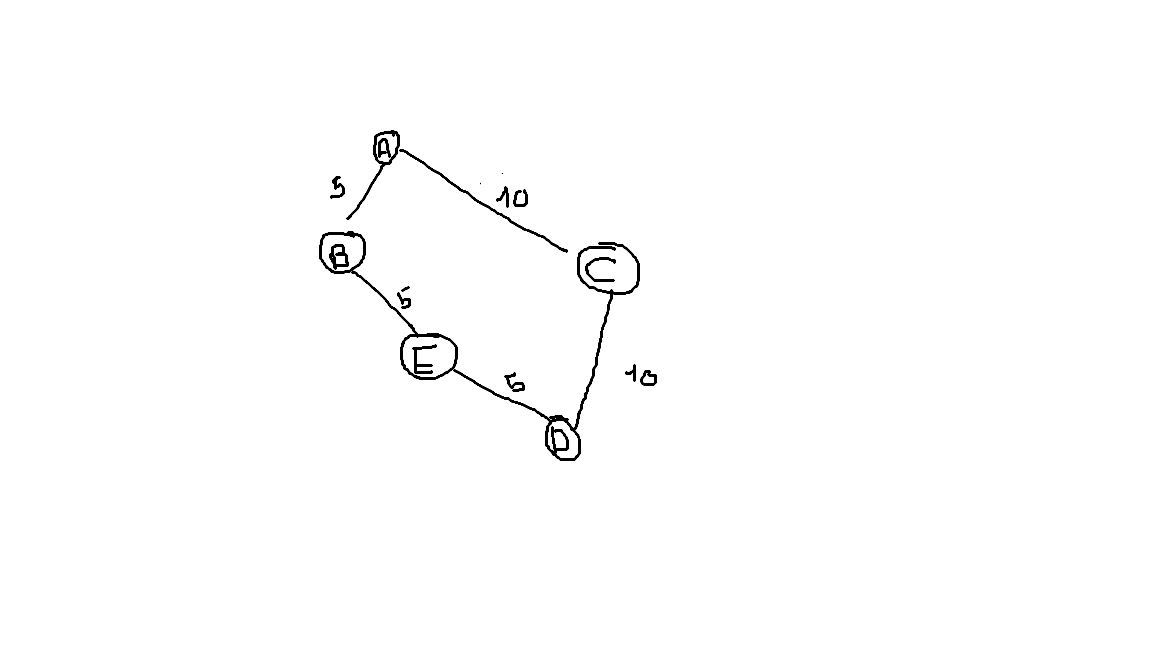

In [216]:
def dijkstra(grafo: Grafo, origen: Nodo, destino:Nodo) -> tuple:
  distancias = grafo.obtener_distancias(origen)
  visitados = set()
  anteriores = {}

  # Inicializando el diccionario con los caminos mas rapidos a cada ciudad
  for nodo in grafo.nodos:
    anteriores[nodo] = None

  for nodo, distancia in distancias.items():
    print(nodo, "-", distancia)
  print("------------------------------------")

  while(len(visitados) < len(grafo.nodos)):
    nodo_actual = None
    menor_distancia = float("inf")

    #Busco el nodo no visitado con menor distancia
    for nodo in grafo.nodos:
      if(nodo not in visitados and distancias[nodo] < menor_distancia):
        menor_distancia = distancias[nodo]
        nodo_actual = nodo

    if nodo_actual is None:
      break

    visitados.add(nodo_actual)

    for vecino,distancia in nodo_actual.vecinos:
      nueva_distancia = distancias[nodo_actual] + distancia
      if(nueva_distancia < distancias[vecino]):
        distancias[vecino] = nueva_distancia
        anteriores[vecino] = nodo_actual

  for nodo, distancia in distancias.items():
    print(nodo, "-", distancia)

  print("------------------------------------")


  for nodo1, nodo2 in anteriores.items():
    print(nodo1, "->", nodo2)

  # Recomponer el camino
  camino = deque()
  nodo_anterior = destino
  while(nodo_anterior is not origen):
    camino.appendleft(nodo_anterior)
    nodo_anterior = anteriores[nodo_anterior]

  camino.appendleft(origen)

  return camino,distancias[destino]

In [217]:
camino_mas_corto, distancia = dijkstra(grafo, a, d) # El camino mas rapido, deberia ser: A,B,E,D 15.

print("El camino es:", end="")
print(camino_mas_corto, sep=" ")
print(" Y mide ", distancia)

A - 0
B - inf
C - inf
D - inf
E - inf
------------------------------------
A - 0
B - 5
C - 10
D - 15
E - 10
------------------------------------
A -> None
B -> A
C -> A
D -> E
E -> B
El camino es:deque([A, B, E, D])
 Y mide  15
